<a href="https://colab.research.google.com/github/Rini43/Case_Study/blob/main/Computer_Vision_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [14]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.datasets import cifar100
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# For Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Model Building
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D,
                                     BatchNormalization, Dropout,
                                     Flatten, Dense)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.initializers import HeNormal

from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam

# Read the Data

In [15]:
# Load dataset

cifar100.load_data()

((array([[[[255, 255, 255],
           [255, 255, 255],
           [255, 255, 255],
           ...,
           [195, 205, 193],
           [212, 224, 204],
           [182, 194, 167]],
  
          [[255, 255, 255],
           [254, 254, 254],
           [254, 254, 254],
           ...,
           [170, 176, 150],
           [161, 168, 130],
           [146, 154, 113]],
  
          [[255, 255, 255],
           [254, 254, 254],
           [255, 255, 255],
           ...,
           [189, 199, 169],
           [166, 178, 130],
           [121, 133,  87]],
  
          ...,
  
          [[148, 185,  79],
           [142, 182,  57],
           [140, 179,  60],
           ...,
           [ 30,  17,   1],
           [ 65,  62,  15],
           [ 76,  77,  20]],
  
          [[122, 157,  66],
           [120, 155,  58],
           [126, 160,  71],
           ...,
           [ 22,  16,   3],
           [ 97, 112,  56],
           [141, 161,  87]],
  
          [[ 87, 122,  41],
           [ 8

In [16]:
(X_train, y_train), (X_test, y_test) = cifar100.load_data()

# EDA

In [17]:
# Dataset information
print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)
print("Testing Images  :", X_test.shape)
print("Testing Labels  :", y_test.shape)

Training Images : (50000, 32, 32, 3)
Training Labels : (50000, 1)
Testing Images  : (10000, 32, 32, 3)
Testing Labels  : (10000, 1)


In [18]:
# Normalize pixel values
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [19]:
print(X_train.dtype)
print(y_train.dtype)

float32
int64


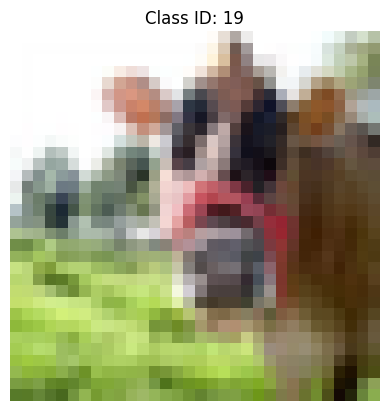

In [20]:
# Display one sample image
plt.imshow(X_train[0])
plt.title(f"Class ID: {y_train[0][0]}")
plt.axis("off")
plt.show()

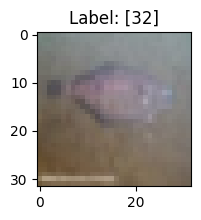

In [21]:
i = 121
plt.figure(figsize=(2,2))
plt.imshow(X_train[i])
plt.title(f"Label: {y_train[i]}")
plt.show()

# Preprocessing

In [22]:
# Checking for missing value

print(np.isnan(X_train).sum())
print(np.isnan(X_test).sum())

0
0


In [23]:
# Check Class Distribution

unique, counts = np.unique(y_train, return_counts=True)

print("Number of Classes :", len(unique))
print("Images per Class :", counts[:10])

Number of Classes : 100
Images per Class : [500 500 500 500 500 500 500 500 500 500]


In [24]:
# For data augmentation
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

train_datagen.fit(X_train)

# It will help to reduce the overfitting

# Model Building

In [25]:
# Build Custom CNN Model
model = Sequential()

# Input Layer
model.add(Input(shape=(32,32,3)))

model.add(Conv2D(32, (3,3), padding='same', activation='relu',
                 kernel_initializer=HeNormal(),
                 kernel_regularizer=l2(0.0005)))

# Normalize the feature maps to improve training stability and convergence
model.add(BatchNormalization())

model.add(Conv2D(32, (3,3), padding='same', activation='relu',
                 kernel_initializer=HeNormal(),
                 kernel_regularizer=l2(0.0005)))
model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))

# Randomly deactivate 25% of neurons to reduce overfitting
model.add(Dropout(0.25))

model.add(Conv2D(64, (3,3), padding='same', activation='relu',
                 kernel_initializer=HeNormal(),
                 kernel_regularizer=l2(0.0005)))
model.add(BatchNormalization())

model.add(Conv2D(64, (3,3), padding='same', activation='relu',
                 kernel_initializer=HeNormal(),
                 kernel_regularizer=l2(0.0005)))
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.30))

model.add(Conv2D(128, (3,3), padding='same', activation='relu',
                 kernel_initializer=HeNormal(),
                 kernel_regularizer=l2(0.0005)))
model.add(BatchNormalization())

model.add(Conv2D(128, (3,3), padding='same', activation='relu',
                 kernel_initializer=HeNormal(),
                 kernel_regularizer=l2(0.0005)))
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.40))

# Flatten the feature maps into a 1D vector before passing them to the Dense layer
model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.50))

# Output Layer
model.add(Dense(100, activation='softmax'))

# model.add(BatchNormalization())
# It does not change the image size.
# It only normalizes the values inside each feature map

# MaxPooling2D((2,2))
# It reduces the image size.


In [26]:
# Display the architecture and summary of the CNN model

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        25,70

 Total params: 839,044 (3.20 MB)

 Trainable params: 838,148 (3.20 MB)

 Non-trainable params: 896 (3.50 KB)

In [27]:
# Compile the model

model.compile(optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [29]:
# Train the model

history = model.fit(
    train_datagen.flow(X_train, y_train, batch_size=64),
    epochs=5,
    validation_data=(X_test, y_test))

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 548s 701ms/step - accuracy: 0.0511 - loss: 4.6012 - val_accuracy: 0.0932 - val_loss: 4.2399
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 536s 685ms/step - accuracy: 0.0737 - loss: 4.3269 - val_accuracy: 0.0899 - val_loss: 4.1197
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 524s 670ms/step - accuracy: 0.0990 - loss: 4.0751 - val_accuracy: 0.1674 - val_loss: 3.6594
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 548s 700ms/step - accuracy: 0.1355 - loss: 3.8451 - val_accuracy: 0.2242 - val_loss: 3.3587
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 541s 691ms/step - accuracy: 0.1722 - loss: 3.6332 - val_accuracy: 0.2327 - val_loss: 3.3146


In [30]:
# Evaluate the trained model on the test dataset

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 74ms/step - accuracy: 0.2327 - loss: 3.3146
Test Loss : 3.3145864009857178
Test Accuracy : 0.23270000517368317


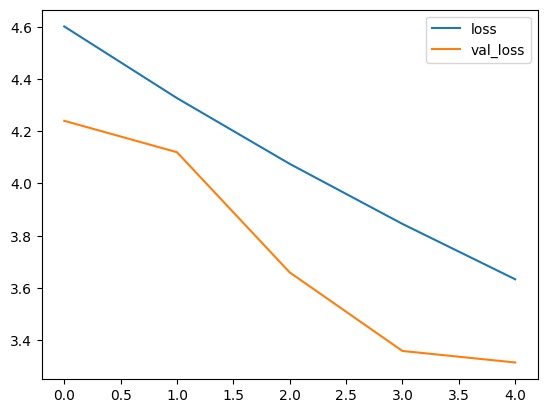

In [31]:
# Plot loss and val_loss

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

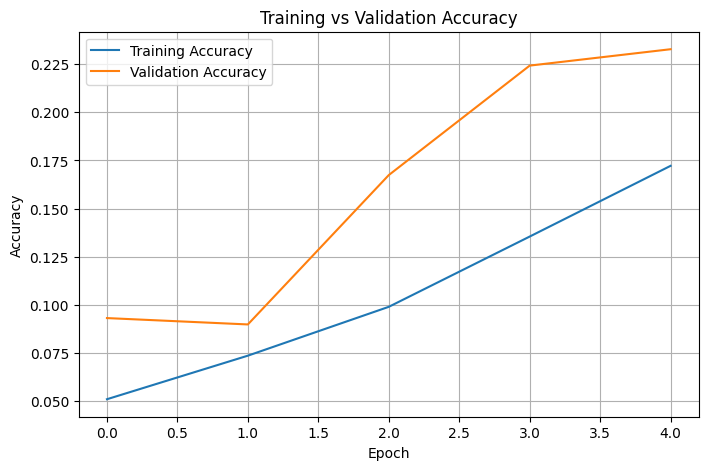

In [33]:
# Plot training and validation accuracy

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

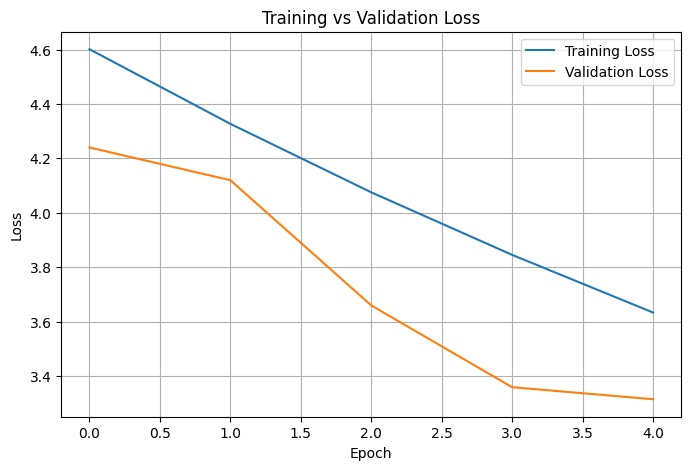

In [34]:
# Plot training and validation loss

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [35]:
# Predict class probabilities for the test images

y_pred = model.predict(X_test)

# Convert probabilities to predicted class labels

y_pred_classes = np.argmax(y_pred, axis=1)

# Convert true labels to 1D

y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 74ms/step


In [36]:
# Display precision, recall, and F1-score for each class

print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.62      0.28      0.39       100
           1       0.16      0.21      0.18       100
           2       0.08      0.02      0.03       100
           3       0.12      0.27      0.16       100
           4       0.06      0.32      0.10       100
           5       0.34      0.13      0.19       100
           6       0.18      0.25      0.21       100
           7       0.14      0.15      0.15       100
           8       0.70      0.07      0.13       100
           9       0.59      0.17      0.26       100
          10       0.27      0.16      0.20       100
          11       0.11      0.02      0.03       100
          12       0.50      0.10      0.17       100
          13       0.17      0.20      0.18       100
          14       0.16      0.22      0.19       100
          15       0.25      0.03      0.05       100
          16       0.29      0.18      0.22       100
          17       0.60    

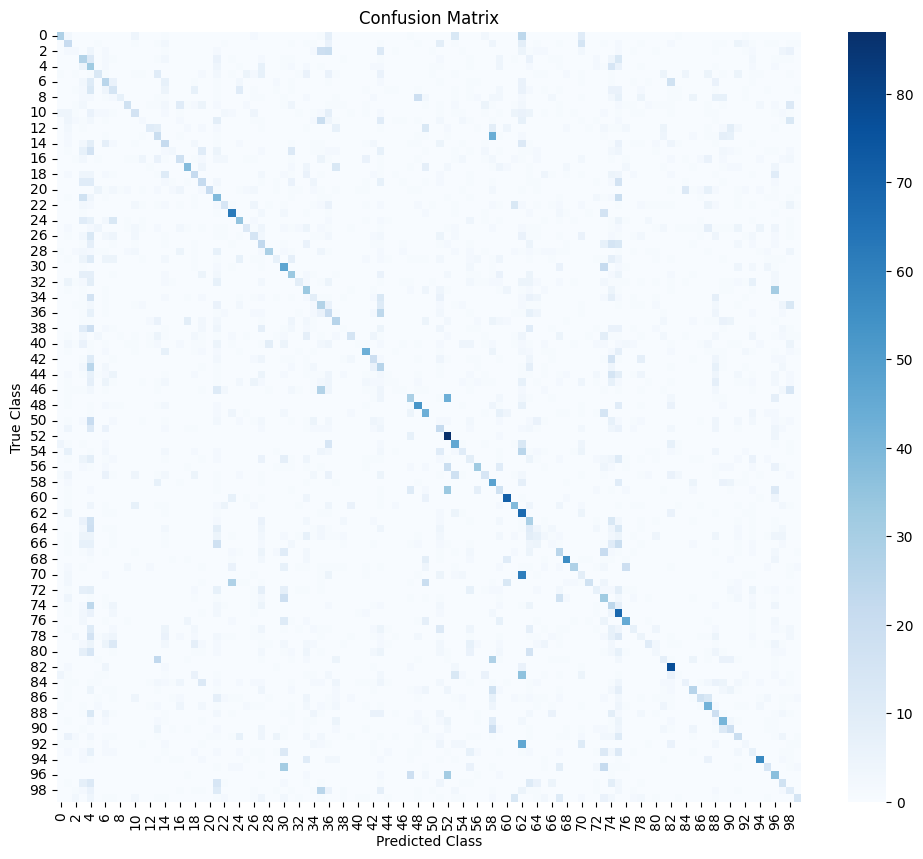

In [37]:
# Compute the confusion matrix

cm = confusion_matrix(y_true, y_pred_classes)

# Plot the confusion matrix

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

In [38]:
# Save the models weights and architecture to a Keras file

model.save('model_weights.keras')

In [40]:
# Reshape the 121st test image to batch size 1 (32x32 pixels, 3 color channels) and get model predictions

pred_probs = model.predict(X_test[121].reshape(1,32,32,3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


In [41]:
# Get the index (class label) with the highest predicted probability

sample_pred = np.argmax(pred_probs)

In [42]:
# Print

print(sample_pred)

26


In [ ]:
# Resize the CIFAR-100 images to 224x224 for VGG16

X_train_vgg = tf.image.resize(X_train, (224,224))
X_test_vgg = tf.image.resize(X_test, (224,224))

In [ ]:
# Load the pre-trained VGG16 model without the top classification layer

vgg_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [ ]:
# Freeze the convolutional layers

for layer in vgg_base.layers:
    layer.trainable = False

In [ ]:
# Build the VGG16 model

vgg_model = Sequential()

# Input Layer
vgg_model.add(Input(shape=(224,224,3)))

# Add the VGG16 base model
vgg_model.add(vgg_base)

# Flatten the extracted feature maps
vgg_model.add(Flatten())

# Fully Connected Layer
vgg_model.add(Dense(256, activation='relu'))

# Apply dropout to reduce overfitting
vgg_model.add(Dropout(0.5))

# Output Layer for CIFAR-100
vgg_model.add(Dense(100, activation='softmax'))

In [ ]:
# Compile the VGG16 model

vgg_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Display the VGG16 model architecture

vgg_model.summary()

In [ ]:
# Train the VGG16 model

history_vgg = vgg_model.fit(
    X_train_vgg,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test_vgg, y_test)
)

In [ ]:
# Evaluate the trained VGG16 model

test_loss, test_accuracy = vgg_model.evaluate(X_test_vgg, y_test)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

In [ ]:
print("Custom CNN Test Accuracy :", custom_test_accuracy)
print("VGG16 Test Accuracy      :", test_accuracy)